In [1]:
from utils.lstm_utils.lstm_preprocessing_utils import WindowAlgPreprocessor

In [11]:
rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[:,:,:]
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[:,:-2:15,1:]
X = rf_preprocessor.patchifier(X=X, window_size=10)
print(f"Shape of input: {X.shape}, Shape of output: {Y.shape}")

Shape of input: (315, 174, 16), Shape of output: (315, 3, 4)



Training model for angle 1/3
Epoch 50/300, Loss: 0.0263
Epoch 100/300, Loss: 0.0152
Epoch 150/300, Loss: 0.0080
Epoch 200/300, Loss: 0.0062
Epoch 250/300, Loss: 0.0049
Epoch 300/300, Loss: 0.0063

Training model for angle 2/3
Epoch 50/300, Loss: 0.0170
Epoch 100/300, Loss: 0.0133
Epoch 150/300, Loss: 0.0048
Epoch 200/300, Loss: 0.0037
Epoch 250/300, Loss: 0.0032
Epoch 300/300, Loss: 0.0032

Training model for angle 3/3
Epoch 50/300, Loss: 0.0106
Epoch 100/300, Loss: 0.0096
Epoch 150/300, Loss: 0.0047
Epoch 200/300, Loss: 0.0034
Epoch 250/300, Loss: 0.0028
Epoch 300/300, Loss: 0.0026


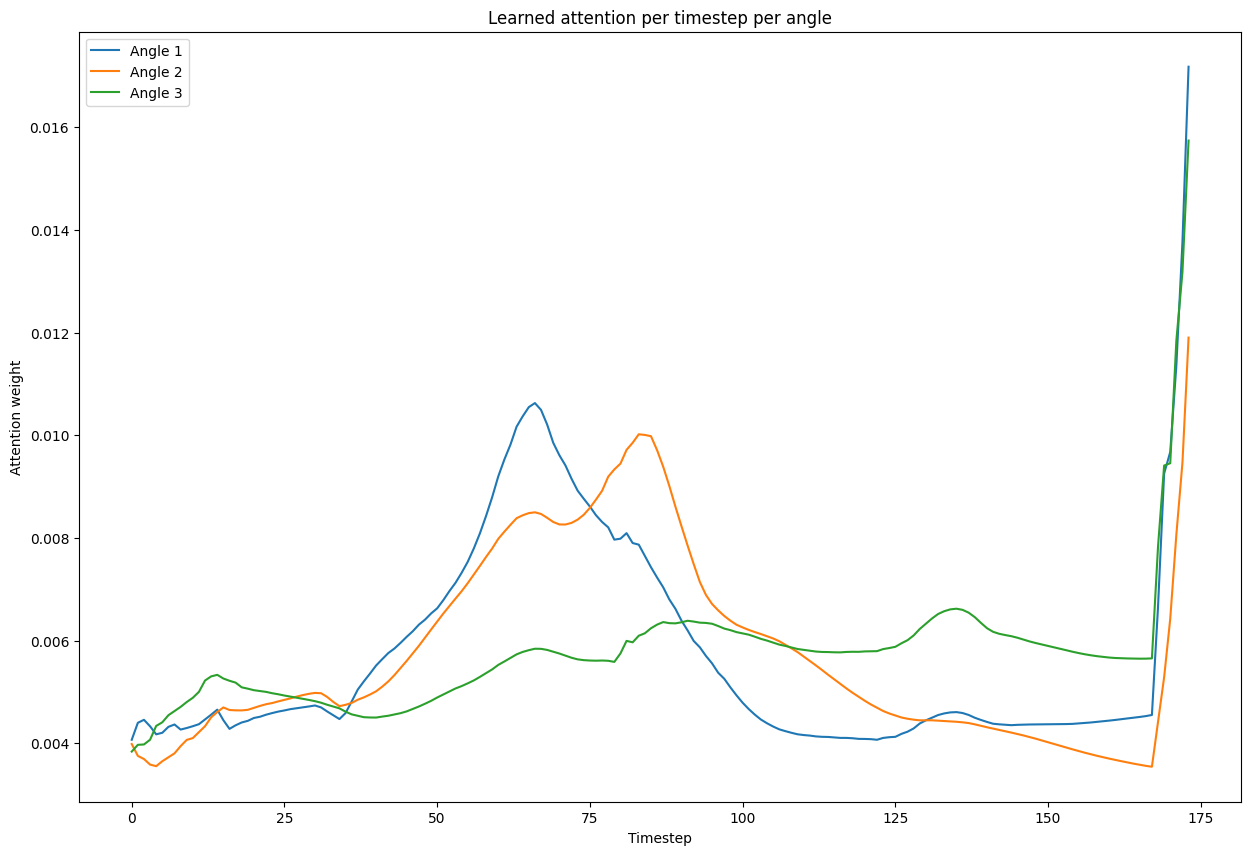

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# --- Improved TCN Block with BatchNorm ---
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, dropout=0.2):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None

    def forward(self, x):
        # Apply causal padding manually
        x_padded = F.pad(x, (self.padding, 0))
        out = self.conv1(x_padded)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Second conv with padding
        out_padded = F.pad(out, (self.padding, 0))
        out = self.conv2(out_padded)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Remove excess padding from the end if any
        if out.size(2) > x.size(2):
            out = out[:, :, :x.size(2)]
            
        res = x if self.downsample is None else self.downsample(x)
        
        # Ensure residual connection matches output size
        if res.size(2) != out.size(2):
            res = res[:, :, :out.size(2)]
            
        return out + res

# --- Improved TCN Model with Better Architecture ---
class ImprovedTCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i-1]
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, stride=1, 
                            dilation=dilation, dropout=dropout)
            )
        self.network = nn.Sequential(*layers)
        
        # Multi-head attention instead of single linear layer
        self.attention = nn.MultiheadAttention(
            embed_dim=num_channels[-1], 
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )
        
        # More sophisticated output layer
        self.fc_layers = nn.Sequential(
            nn.Linear(num_channels[-1], 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size)
        )
        
        # Layer normalization
        self.layer_norm = nn.LayerNorm(num_channels[-1])

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, features, seq_len)
        y = self.network(x)
        y = y.transpose(1, 2)  # (batch, seq_len, channels)
        
        # Layer normalization
        y = self.layer_norm(y)
        
        # Multi-head attention
        attn_output, attn_weights = self.attention(y, y, y)
        
        # Use both original and attended features
        combined = y + attn_output  # residual connection
        
        # Global average pooling + max pooling
        avg_pool = combined.mean(dim=1)
        max_pool, _ = combined.max(dim=1)
        pooled = torch.cat([avg_pool, max_pool], dim=1)  # concatenate both
        
        # Additional FC layer for combined features
        pooled = nn.Linear(pooled.size(1), 128)(pooled)
        pooled = F.relu(pooled)
        pooled = self.dropout(pooled)
        
        return self.fc_layers(pooled), attn_weights

# --- Data Preparation with Normalization ---
def prepare_data(X, Y):
    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    Y_tensor = torch.tensor(Y, dtype=torch.float32)
    
    # Normalize features (important for convergence)
    X_mean = X_tensor.mean(dim=(0, 1), keepdim=True)
    X_std = X_tensor.std(dim=(0, 1), keepdim=True)
    X_tensor = (X_tensor - X_mean) / (X_std + 1e-8)
    
    # Normalize targets
    Y_mean = Y_tensor.mean(dim=(0, 2), keepdim=True)
    Y_std = Y_tensor.std(dim=(0, 2), keepdim=True)
    Y_tensor = (Y_tensor - Y_mean) / (Y_std + 1e-8)
    
    return X_tensor, Y_tensor, (X_mean, X_std, Y_mean, Y_std)

# --- Training Function with Validation ---
def train_models(X_tensor, Y_tensor, num_angles, input_size, output_size):
    # Hyperparameters
    num_channels = [64, 128, 256]  # Increased channels
    kernel_size = 3
    dropout = 0.2
    lr = 0.001
    epochs = 300
    train_ratio = 0.8
    
    # Split data into train/validation
    dataset_size = len(X_tensor)
    indices = list(range(dataset_size))
    split = int(np.floor(train_ratio * dataset_size))
    
    train_indices = indices[:split]
    val_indices = indices[split:]
    
    X_train = X_tensor[train_indices]
    Y_train = Y_tensor[train_indices]
    X_val = X_tensor[val_indices]
    Y_val = Y_tensor[val_indices]
    
    models = []
    train_losses = []
    val_losses = []
    
    for angle in range(num_angles):
        print(f"\nTraining model for angle {angle+1}/{num_angles}")
        y_angle_train = Y_train[:, angle, :]
        y_angle_val = Y_val[:, angle, :]
        
        model = ImprovedTCN(input_size, output_size, num_channels, kernel_size, dropout)
        criterion = nn.MSELoss()
        
        # Use AdamW with weight decay for better regularization
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        
        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=15, verbose=True
        )
        
        angle_train_losses = []
        angle_val_losses = []
        
        for epoch in range(epochs):
            # Training
            model.train()
            optimizer.zero_grad()
            output, _ = model(X_train)
            train_loss = criterion(output, y_angle_train)
            train_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_output, _ = model(X_val)
                val_loss = criterion(val_output, y_angle_val)
            
            scheduler.step(val_loss)
            
            angle_train_losses.append(train_loss.item())
            angle_val_losses.append(val_loss.item())
            
            if (epoch+1) % 50 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, "
                      f"Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}")
        
        models.append(model)
        train_losses.append(angle_train_losses)
        val_losses.append(angle_val_losses)
        
        # Plot training history for this angle
        plt.figure(figsize=(10, 4))
        plt.plot(angle_train_losses, label='Train Loss')
        plt.plot(angle_val_losses, label='Val Loss')
        plt.title(f'Training History - Angle {angle+1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
    
    return models, train_losses, val_losses

# --- Get Attention Weights ---
def get_attention_weights(models, X_tensor):
    attentions = []
    
    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            _, attn_weights = model(X_tensor)
            # attn_weights shape: (batch, seq_len, seq_len) for multi-head attention
            # Take mean over batch and attention heads
            attn_mean = attn_weights.mean(dim=0).mean(dim=0).numpy()  # average over batch and heads
            attentions.append(attn_mean)
    
    return attentions

# --- Main Execution ---
if __name__ == "__main__":
    # Assuming you have X and Y data loaded
    # X shape: (samples, seq_len, features)
    # Y shape: (samples, num_angles, output_size)
    
    # Prepare data
    X_tensor, Y_tensor, norm_params = prepare_data(X, Y)
    
    # Get dimensions
    input_size = X_tensor.shape[2]  # 16 features
    output_size = Y_tensor.shape[2]  # 4 output values
    num_angles = Y_tensor.shape[1]   # number of angles
    
    print(f"Data shapes - X: {X_tensor.shape}, Y: {Y_tensor.shape}")
    print(f"Input size: {input_size}, Output size: {output_size}, Num angles: {num_angles}")
    
    # Train models
    models, train_losses, val_losses = train_models(
        X_tensor, Y_tensor, num_angles, input_size, output_size
    )
    
    # Get attention weights
    attentions = get_attention_weights(models, X_tensor)
    
    # --- Plot attention weights ---
    timesteps = np.arange(X_tensor.shape[1])
    plt.figure(figsize=(15, 10))
    for i, attn in enumerate(attentions):
        # For multi-head attention, we might need to adjust how we plot
        plt.plot(timesteps[:len(attn)], attn, label=f"Angle {i+1}", alpha=0.7)
    
    plt.title("Learned Attention Weights per Angle")
    plt.xlabel("Timestep")
    plt.ylabel("Attention Weight")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- Final Evaluation ---
    print("\n=== Final Evaluation ===")
    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            predictions, _ = model(X_tensor)
            actual = Y_tensor[:, i, :]
            mse = F.mse_loss(predictions, actual).item()
            print(f"Angle {i+1} - Final MSE: {mse:.6f}")
    
    print("\nTraining completed!")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# --- Improved TCN Block with BatchNorm ---
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, dropout=0.2):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None

    def forward(self, x):
        # Apply causal padding manually
        x_padded = F.pad(x, (self.padding, 0))
        out = self.conv1(x_padded)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Second conv with padding
        out_padded = F.pad(out, (self.padding, 0))
        out = self.conv2(out_padded)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Remove excess padding from the end if any
        if out.size(2) > x.size(2):
            out = out[:, :, :x.size(2)]
            
        res = x if self.downsample is None else self.downsample(x)
        
        # Ensure residual connection matches output size
        if res.size(2) != out.size(2):
            res = res[:, :, :out.size(2)]
            
        return out + res

# --- Improved TCN Model with Better Architecture ---
class ImprovedTCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i-1]
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, stride=1, 
                            dilation=dilation, dropout=dropout)
            )
        self.network = nn.Sequential(*layers)
        
        # Multi-head attention instead of single linear layer
        self.attention = nn.MultiheadAttention(
            embed_dim=num_channels[-1], 
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )
        
        # More sophisticated output layer
        self.fc_layers = nn.Sequential(
            nn.Linear(num_channels[-1], 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size)
        )
        
        # Layer normalization
        self.layer_norm = nn.LayerNorm(num_channels[-1])

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, features, seq_len)
        y = self.network(x)
        y = y.transpose(1, 2)  # (batch, seq_len, channels)
        
        # Layer normalization
        y = self.layer_norm(y)
        
        # Multi-head attention
        attn_output, attn_weights = self.attention(y, y, y)
        
        # Use both original and attended features
        combined = y + attn_output  # residual connection
        
        # Global average pooling + max pooling
        avg_pool = combined.mean(dim=1)
        max_pool, _ = combined.max(dim=1)
        pooled = torch.cat([avg_pool, max_pool], dim=1)  # concatenate both
        
        # Additional FC layer for combined features
        pooled = nn.Linear(pooled.size(1), 128)(pooled)
        pooled = F.relu(pooled)
        
        return self.fc_layers(pooled), attn_weights

# --- Data Preparation with Normalization ---
def prepare_data(X, Y):
    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    Y_tensor = torch.tensor(Y, dtype=torch.float32)
    
    # Normalize features (important for convergence)
    X_mean = X_tensor.mean(dim=(0, 1), keepdim=True)
    X_std = X_tensor.std(dim=(0, 1), keepdim=True)
    X_tensor = (X_tensor - X_mean) / (X_std + 1e-8)
    
    # Normalize targets
    Y_mean = Y_tensor.mean(dim=(0, 2), keepdim=True)
    Y_std = Y_tensor.std(dim=(0, 2), keepdim=True)
    Y_tensor = (Y_tensor - Y_mean) / (Y_std + 1e-8)
    
    return X_tensor, Y_tensor, (X_mean, X_std, Y_mean, Y_std)

# --- Training Function with Validation ---
def train_models(X_tensor, Y_tensor, num_angles, input_size, output_size):
    # Hyperparameters
    num_channels = [64, 128, 256]  # Increased channels
    kernel_size = 3
    dropout = 0.2
    lr = 0.001
    epochs = 300
    train_ratio = 0.8
    
    # Split data into train/validation
    dataset_size = len(X_tensor)
    indices = list(range(dataset_size))
    split = int(np.floor(train_ratio * dataset_size))
    
    train_indices = indices[:split]
    val_indices = indices[split:]
    
    X_train = X_tensor[train_indices]
    Y_train = Y_tensor[train_indices]
    X_val = X_tensor[val_indices]
    Y_val = Y_tensor[val_indices]
    
    models = []
    train_losses = []
    val_losses = []
    
    for angle in range(num_angles):
        print(f"\nTraining model for angle {angle+1}/{num_angles}")
        y_angle_train = Y_train[:, angle, :]
        y_angle_val = Y_val[:, angle, :]
        
        model = ImprovedTCN(input_size, output_size, num_channels, kernel_size, dropout)
        criterion = nn.MSELoss()
        
        # Use AdamW with weight decay for better regularization
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        
        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=15
        )
        
        angle_train_losses = []
        angle_val_losses = []
        
        for epoch in range(epochs):
            # Training
            model.train()
            optimizer.zero_grad()
            output, _ = model(X_train)
            train_loss = criterion(output, y_angle_train)
            train_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_output, _ = model(X_val)
                val_loss = criterion(val_output, y_angle_val)
            
            scheduler.step(val_loss)
            
            angle_train_losses.append(train_loss.item())
            angle_val_losses.append(val_loss.item())
            
            if (epoch+1) % 50 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, "
                      f"Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}")
        
        models.append(model)
        train_losses.append(angle_train_losses)
        val_losses.append(angle_val_losses)
        
        # Plot training history for this angle
        plt.figure(figsize=(10, 4))
        plt.plot(angle_train_losses, label='Train Loss')
        plt.plot(angle_val_losses, label='Val Loss')
        plt.title(f'Training History - Angle {angle+1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
    
    return models, train_losses, val_losses

# --- Get Attention Weights ---
def get_attention_weights(models, X_tensor):
    attentions = []
    
    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            _, attn_weights = model(X_tensor)
            # attn_weights shape: (batch, seq_len, seq_len) for multi-head attention
            # Take mean over batch and attention heads
            attn_mean = attn_weights.mean(dim=0).mean(dim=0).numpy()  # average over batch and heads
            attentions.append(attn_mean)
    
    return attentions

# --- Main Execution ---
if __name__ == "__main__":
    # Assuming you have X and Y data loaded
    # X shape: (samples, seq_len, features)
    # Y shape: (samples, num_angles, output_size)
    
    # Prepare data
    X_tensor, Y_tensor, norm_params = prepare_data(X, Y)
    
    # Get dimensions
    input_size = X_tensor.shape[2]  # 16 features
    output_size = Y_tensor.shape[2]  # 4 output values
    num_angles = Y_tensor.shape[1]   # number of angles
    
    print(f"Data shapes - X: {X_tensor.shape}, Y: {Y_tensor.shape}")
    print(f"Input size: {input_size}, Output size: {output_size}, Num angles: {num_angles}")
    
    # Train models
    models, train_losses, val_losses = train_models(
        X_tensor, Y_tensor, num_angles, input_size, output_size
    )
    
    # Get attention weights
    attentions = get_attention_weights(models, X_tensor)
    
    # --- Plot attention weights ---
    timesteps = np.arange(X_tensor.shape[1])
    plt.figure(figsize=(15, 10))
    for i, attn in enumerate(attentions):
        # For multi-head attention, we might need to adjust how we plot
        plt.plot(timesteps[:len(attn)], attn, label=f"Angle {i+1}", alpha=0.7)
    
    plt.title("Learned Attention Weights per Angle")
    plt.xlabel("Timestep")
    plt.ylabel("Attention Weight")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- Final Evaluation ---
    print("\n=== Final Evaluation ===")
    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            predictions, _ = model(X_tensor)
            actual = Y_tensor[:, i, :]
            mse = F.mse_loss(predictions, actual).item()
            print(f"Angle {i+1} - Final MSE: {mse:.6f}")
    
    print("\nTraining completed!")

Data shapes - X: torch.Size([315, 174, 16]), Y: torch.Size([315, 3, 4])
Input size: 16, Output size: 4, Num angles: 3

Training model for angle 1/3


AttributeError: 'ImprovedTCN' object has no attribute 'dropout'

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- Assume X_tensor and Y_tensor are already prepared ---
# X_tensor: (315, 174, 16)
# Y_tensor: (315, 5, 4)

# --- Use the trained models from previous code ---
# models: list of 5 trained models, one per angle
num_angles = Y_tensor.shape[1]
output_size = Y_tensor.shape[2]
timesteps = np.arange(X_tensor.shape[1])

# --- Pick a sample to visualize ---
sample_idx = 0
x_sample = X_tensor[sample_idx:sample_idx+1]  # shape (1, 174, 16)
y_true = Y_tensor[sample_idx].detach().numpy()  # shape (5,4)

# --- Predictions per angle ---
y_pred = []
for model in models:
    model.eval()
    with torch.no_grad():
        pred = model(x_sample).numpy()  # shape (1, 4)
        y_pred.append(pred[0])
y_pred = np.array(y_pred)  # shape (5,4)

# --- Plot predictions and importance ---
fig, axes = plt.subplots(2,1, figsize=(14,8))

# Top: Predictions vs True
angles = np.arange(1, num_angles+1)
for f in range(output_size):
    axes[0].plot(angles, y_true[:,f], 'o-', label=f'True Feature {f+1}')
    axes[0].plot(angles, y_pred[:,f], 'x--', label=f'Pred Feature {f+1}')
axes[0].set_title(f'Predictions vs True Values (Sample {sample_idx})')
axes[0].set_xlabel('Angle')
axes[0].set_ylabel('Output Value')
axes[0].legend()

# Bottom: Importance per timestep
for angle_idx, imp in enumerate(importances):
    axes[1].plot(timesteps, imp, label=f'Angle {angle_idx+1}')
axes[1].set_title('Estimated Timestep Importance per Angle')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Importance')
axes[1].legend()

plt.tight_layout()
plt.show()


AttributeError: 'tuple' object has no attribute 'numpy'